# Exploratory Data Analysis of Energy Consumption in a Data Center

**Course:** Introduction to Data Science  
**Assignment:** Exploratory Data Analysis (EDA)  
**Topic:** Data center energy efficiency, power consumption, and weather context

This notebook performs an exploratory data analysis of a data center energy dataset. The analysis follows a full EDA workflow: dataset description, metadata inspection, data loading, data quality checks, univariate analysis, outlier detection, correlations, visualization, time-index analysis, engineering features, and final insights.

## 1. Introduction

Data centers consume electrical energy through IT equipment, cooling systems, pumps, HVAC equipment, lighting, and auxiliary systems. Energy efficiency is commonly analyzed using operational measurements such as IT power, cooling power, total facility power, and PUE.

The purpose of this notebook is to understand the structure, quality, and main relationships in a data center operational dataset.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display
from pandas.api.types import is_datetime64_any_dtype

sns.set_theme(style="whitegrid")

RAW_DATA_DIR = Path("data") / "raw"
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

print("Raw data folder:", RAW_DATA_DIR)
print("Folder exists:", RAW_DATA_DIR.exists())

Raw data folder: data\raw
Folder exists: True


## 2. Dataset Source and Domain Context

The dataset used in this notebook contains data center power metrics and outside weather station measurements. The power metrics include variables such as IT power, cooling power, HVAC power, pump power, PUE, and related efficiency measures. The weather data includes outdoor air temperature and humidity.

The data appears to be operational time-series data collected from meters and sensors. This means the data was likely collected for monitoring, energy management, operational analysis, and efficiency tracking rather than for a controlled research experiment.

From an electrical engineering perspective, this dataset is relevant because it connects power consumption, cooling demand, environmental conditions, and energy efficiency.

## 3. File and Metadata Analysis

This section inspects the raw CSV files before loading them fully. Since the files may be large, the code reads only metadata and column headers at this stage.

In [9]:
# Inspect raw CSV files without loading the full data into memory

raw_csv_files = sorted(RAW_DATA_DIR.glob("*.csv"))

file_metadata_rows = []

for file_path in raw_csv_files:
    columns = pd.read_csv(file_path, nrows=0).columns.tolist()
    file_metadata_rows.append({
        "file_name": file_path.name,
        "file_size_mb": round(file_path.stat().st_size / (1024 ** 2), 2),
        "number_of_columns": len(columns),
        "columns_preview": columns[:8]
    })

file_metadata_summary = pd.DataFrame(file_metadata_rows)
file_metadata_summary

,file_name,file_size_mb,number_of_columns,columns_preview
0,data_center_power_metrics.csv,354.26,6,"[tags, ts, outdoor_air_humidity, outdoor_air_t..."
1,data_center_weather.csv,546.64,11,"[tags, ts, cooling_kw, energy_reuse, ere, hvac..."


## 4. Data Loading

The raw dataset contains large CSV files. To keep the notebook efficient and stable, the loading process reads the files in chunks and creates a smaller working dataset.

The working dataset uses the first 1,500 valid chronological records after basic timestamp cleaning and weather matching. This satisfies the assignment requirement of at least 1,000 rows while keeping the analysis computationally manageable.

In [10]:
# Detect the power metrics file and the weather file based on their columns

power_file_path = None
weather_file_path = None

for file_path in raw_csv_files:
    columns = pd.read_csv(file_path, nrows=0).columns.tolist()

    if "pue" in columns and "it_power_kw" in columns:
        power_file_path = file_path

    if "outdoor_air_temp" in columns and "outdoor_air_humidity" in columns:
        weather_file_path = file_path

print("Power file detected:", power_file_path)
print("Weather file detected:", weather_file_path)

if power_file_path is None:
    raise FileNotFoundError("Power metrics CSV file was not found in data/raw.")

if weather_file_path is None:
    raise FileNotFoundError("Weather CSV file was not found in data/raw.")

Power file detected: data\raw\data_center_weather.csv
Weather file detected: data\raw\data_center_power_metrics.csv


In [11]:
# Helper function for timestamp cleaning

def clean_timestamp_column(dataframe, timestamp_column="ts"):
    cleaned_timestamp = (
        dataframe[timestamp_column]
        .astype("string")
        .str.replace(r"\s*\(.*?\)\s*$", "", regex=True)
    )

    return pd.to_datetime(
        cleaned_timestamp,
        errors="coerce",
        utc=True
    )

In [12]:
# Load a safe chronological sample from the power metrics file

power_columns_to_load = [
    "tags",
    "ts",
    "cooling_kw",
    "energy_reuse",
    "ere",
    "hvac_kw",
    "it_power_kw",
    "plug_and_light_kw",
    "pue",
    "pump_kw",
    "day"
]

minimum_valid_timestamp = pd.Timestamp("2016-06-12", tz="UTC")

power_chunks = []
target_power_rows = 3000

for chunk in pd.read_csv(
    power_file_path,
    usecols=power_columns_to_load,
    chunksize=100_000,
    low_memory=False
):
    chunk["ts"] = clean_timestamp_column(chunk, "ts")
    chunk = chunk.dropna(subset=["ts"])
    chunk = chunk[chunk["ts"] >= minimum_valid_timestamp]
    chunk = chunk.dropna(subset=["ts", "pue", "it_power_kw"])

    power_chunks.append(chunk)

    current_row_count = sum(len(power_chunk) for power_chunk in power_chunks)

    if current_row_count >= target_power_rows:
        break

power_sample_df = (
    pd.concat(power_chunks, ignore_index=True)
    .sort_values("ts")
    .head(target_power_rows)
    .reset_index(drop=True)
)

print("Power sample shape:", power_sample_df.shape)
print("Power sample time range:", power_sample_df["ts"].min(), "to", power_sample_df["ts"].max())

display(power_sample_df.head())

Power sample shape: (3000, 11)
Power sample time range: 2016-07-28 08:45:24+00:00 to 2016-07-30 10:44:24+00:00


,tags,ts,cooling_kw,energy_reuse,ere,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day
0,NaN,2016-07-28 08:45:24+00:00,7.47,NaN,0.936,9.06,887.73,2.46,1.034,11.52,28
1,NaN,2016-07-28 08:46:22+00:00,7.77,NaN,0.936,9.44,885.44,2.46,1.035,11.22,28
2,NaN,2016-07-28 08:47:22+00:00,7.77,NaN,0.941,9.34,885.08,2.44,1.035,11.22,28
3,NaN,2016-07-28 08:48:22+00:00,7.67,NaN,0.947,10.06,887.15,2.46,1.036,11.72,28
4,NaN,2016-07-28 08:49:23+00:00,7.67,NaN,0.950,10.01,885.13,2.44,1.036,11.72,28


In [13]:
# Load weather rows that match the selected power time range

weather_columns_to_load = [
    "tags",
    "ts",
    "outdoor_air_humidity",
    "outdoor_air_temp",
    "unit",
    "day"
]

weather_start_time = power_sample_df["ts"].min() - pd.Timedelta("5min")
weather_end_time = power_sample_df["ts"].max() + pd.Timedelta("5min")

weather_chunks = []

for chunk in pd.read_csv(
    weather_file_path,
    usecols=weather_columns_to_load,
    chunksize=100_000,
    low_memory=False
):
    chunk["ts"] = clean_timestamp_column(chunk, "ts")
    chunk = chunk.dropna(subset=["ts"])

    chunk = chunk[
        (chunk["ts"] >= weather_start_time) &
        (chunk["ts"] <= weather_end_time)
    ]

    if len(chunk) > 0:
        weather_chunks.append(chunk)

if len(weather_chunks) == 0:
    raise ValueError("No weather rows were found in the selected power time range.")

weather_sample_df = (
    pd.concat(weather_chunks, ignore_index=True)
    .sort_values("ts")
    .reset_index(drop=True)
)

print("Weather sample shape:", weather_sample_df.shape)
print("Weather sample time range:", weather_sample_df["ts"].min(), "to", weather_sample_df["ts"].max())

display(weather_sample_df.head())

Weather sample shape: (3010, 6)
Weather sample time range: 2016-07-28 08:40:24+00:00 to 2016-07-30 10:49:24+00:00


,tags,ts,outdoor_air_humidity,outdoor_air_temp,unit,day
0,NaN,2016-07-28 08:40:24+00:00,63.9,67.5,NaN,28
1,NaN,2016-07-28 08:41:23+00:00,63.9,67.5,NaN,28
2,NaN,2016-07-28 08:42:23+00:00,63.8,67.5,NaN,28
3,NaN,2016-07-28 08:43:22+00:00,63.9,67.5,NaN,28
4,NaN,2016-07-28 08:44:22+00:00,63.8,67.4,NaN,28


In [14]:
# Merge power and weather records using nearest timestamp matching

power_sample_df = power_sample_df.sort_values("ts").reset_index(drop=True)
weather_sample_df = weather_sample_df.sort_values("ts").reset_index(drop=True)

data_center_df = pd.merge_asof(
    power_sample_df,
    weather_sample_df,
    on="ts",
    direction="nearest",
    tolerance=pd.Timedelta("2min"),
    suffixes=("_power", "_weather")
)

data_center_df = data_center_df.dropna(
    subset=["pue", "it_power_kw", "outdoor_air_temp", "outdoor_air_humidity"]
)

eda_df = data_center_df.head(1500).copy().reset_index(drop=True)

print("EDA working dataset shape:", eda_df.shape)
print("Time range:", eda_df["ts"].min(), "to", eda_df["ts"].max())

display(eda_df.head())

EDA working dataset shape: (1500, 16)
Time range: 2016-07-28 08:45:24+00:00 to 2016-07-29 09:44:21+00:00


,tags_power,ts,cooling_kw,energy_reuse,ere,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,day_power,tags_weather,outdoor_air_humidity,outdoor_air_temp,unit,day_weather
0,NaN,2016-07-28 08:45:24+00:00,7.47,NaN,0.936,9.06,887.73,2.46,1.034,11.52,28,NaN,63.9,67.4,NaN,28
1,NaN,2016-07-28 08:46:22+00:00,7.77,NaN,0.936,9.44,885.44,2.46,1.035,11.22,28,NaN,63.9,67.4,NaN,28
2,NaN,2016-07-28 08:47:22+00:00,7.77,NaN,0.941,9.34,885.08,2.44,1.035,11.22,28,NaN,63.9,67.3,NaN,28
3,NaN,2016-07-28 08:48:22+00:00,7.67,NaN,0.947,10.06,887.15,2.46,1.036,11.72,28,NaN,63.9,67.1,NaN,28
4,NaN,2016-07-28 08:49:23+00:00,7.67,NaN,0.950,10.01,885.13,2.44,1.036,11.72,28,NaN,63.9,67.0,NaN,28


## 5. Data Structure

This section examines the structure of the working dataset, including rows, columns, data types, and basic descriptive information.

In [15]:
# Data structure overview

print("Rows and columns:", eda_df.shape)

structure_summary = pd.DataFrame({
    "column_name": eda_df.columns,
    "data_type": eda_df.dtypes.astype(str).values,
    "non_null_count": eda_df.notna().sum().values,
    "missing_count": eda_df.isna().sum().values,
    "unique_values": eda_df.nunique().values
})

display(structure_summary)
display(eda_df.describe(include="all").T)

Rows and columns: (1500, 16)


,column_name,data_type,non_null_count,missing_count,unique_values
0,tags_power,float64,0,1500,0
1,ts,"datetime64[us, UTC]",1500,0,1500
2,cooling_kw,float64,1500,0,144
3,energy_reuse,float64,0,1500,0
4,ere,float64,1500,0,104
5,hvac_kw,float64,1500,0,232
6,it_power_kw,float64,1500,0,1248
7,plug_and_light_kw,float64,1500,0,114
8,pue,float64,1500,0,26
9,pump_kw,float64,1500,0,39


,count,mean,min,25%,50%,75%,max,std
tags_power,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ts,1500,2016-07-28 21:14:52.169333+00:00,2016-07-28 08:45:24+00:00,2016-07-28 15:00:07.500000+00:00,2016-07-28 21:14:53+00:00,2016-07-29 03:29:37+00:00,2016-07-29 09:44:21+00:00,NaN
cooling_kw,1500.0,12.2426,4.87,8.77,12.17,14.97,19.27,4.274736
energy_reuse,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ere,1500.0,0.969907,0.897,0.953,0.974,0.989,1.005,0.022114
hvac_kw,1500.0,8.847607,5.71,8.39,8.94,9.42,11.27,0.869589
it_power_kw,1500.0,904.7035,861.33,883.7725,912.085,922.6525,933.33,19.78907
plug_and_light_kw,1500.0,3.908727,2.41,2.44,2.46,6.46,8.49,2.150793
pue,1500.0,1.040306,1.029,1.036,1.041,1.045,1.054,0.00568
pump_kw,1500.0,11.503927,10.52,11.23,11.52,11.72,12.42,0.335226


## 6. Engineering Features

Several engineering and time-based features are created to support the analysis.

In [16]:
# Create engineering and time-based features

eda_df["hour_of_day"] = eda_df["ts"].dt.hour
eda_df["day_of_week"] = eda_df["ts"].dt.day_name()
eda_df["month"] = eda_df["ts"].dt.month
eda_df["date"] = eda_df["ts"].dt.date
eda_df["is_weekend"] = eda_df["ts"].dt.dayofweek.isin([5, 6])

power_component_columns = [
    "cooling_kw",
    "hvac_kw",
    "it_power_kw",
    "plug_and_light_kw",
    "pump_kw"
]

available_power_columns = [
    column for column in power_component_columns
    if column in eda_df.columns
]

eda_df["total_facility_kw"] = eda_df[available_power_columns].sum(
    axis=1,
    min_count=1
)

eda_df["cooling_to_it_ratio"] = (
    eda_df["cooling_kw"] / eda_df["it_power_kw"].replace(0, np.nan)
)

eda_df["load_level"] = pd.qcut(
    eda_df["total_facility_kw"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

eda_df["pue_category"] = pd.cut(
    eda_df["pue"],
    bins=[0, 1.2, 1.5, 2.0, np.inf],
    labels=["Excellent", "Good", "Moderate", "High"],
    include_lowest=True
)

display(eda_df.head())

,tags_power,ts,cooling_kw,energy_reuse,ere,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,...,day_weather,hour_of_day,day_of_week,month,date,is_weekend,total_facility_kw,cooling_to_it_ratio,load_level,pue_category
0,NaN,2016-07-28 08:45:24+00:00,7.47,NaN,0.936,9.06,887.73,2.46,1.034,11.52,...,28,8,Thursday,7,2016-07-28,False,918.24,0.008415,Low,Excellent
1,NaN,2016-07-28 08:46:22+00:00,7.77,NaN,0.936,9.44,885.44,2.46,1.035,11.22,...,28,8,Thursday,7,2016-07-28,False,916.33,0.008775,Low,Excellent
2,NaN,2016-07-28 08:47:22+00:00,7.77,NaN,0.941,9.34,885.08,2.44,1.035,11.22,...,28,8,Thursday,7,2016-07-28,False,915.85,0.008779,Low,Excellent
3,NaN,2016-07-28 08:48:22+00:00,7.67,NaN,0.947,10.06,887.15,2.46,1.036,11.72,...,28,8,Thursday,7,2016-07-28,False,919.06,0.008646,Low,Excellent
4,NaN,2016-07-28 08:49:23+00:00,7.67,NaN,0.950,10.01,885.13,2.44,1.036,11.72,...,28,8,Thursday,7,2016-07-28,False,916.97,0.008665,Low,Excellent


In [ ]:
# Verify basic assignment requirements

number_of_rows, number_of_columns = eda_df.shape

numeric_columns = eda_df.select_dtypes(include=np.number).columns.tolist()

# Convert selected time-derived categorical columns to string type
if "day_of_week" in eda_df.columns:
    eda_df["day_of_week"] = eda_df["day_of_week"].astype("string")

if "date" in eda_df.columns:
    eda_df["date"] = eda_df["date"].astype("string")

categorical_columns = eda_df.select_dtypes(
    include=["string", "category", "bool"]
).columns.tolist()

datetime_columns = [
    column for column in eda_df.columns
    if is_datetime64_any_dtype(eda_df[column])
]

requirements_summary = pd.DataFrame({
    "Requirement": [
        "At least 1000 rows",
        "At least 10 columns",
        "Numeric variables",
        "Categorical variables",
        "Time variable"
    ],
    "Result": [
        number_of_rows,
        number_of_columns,
        len(numeric_columns),
        len(categorical_columns),
        len(datetime_columns)
    ],
    "Pass": [
        number_of_rows >= 1000,A
        number_of_columns >= 10,
        len(numeric_columns) > 0,
        len(categorical_columns) > 0,
        len(datetime_columns) > 0
    ]
})

requirements_summary

,Requirement,Result,Pass
0,At least 1000 rows,1500,True
1,At least 10 columns,25,True
2,Numeric variables,19,True
3,Categorical variables,5,True
4,Time variable,1,True


## 7. Data Quality and Completeness

This section evaluates missing values, duplicates, suspicious values, and cardinality. In operational sensor data, quality issues may represent communication gaps, sensor faults, maintenance periods, or real engineering behavior.

In [18]:
# Data quality overview

def get_example_values(series, number_of_examples=3):
    example_values = series.dropna().astype(str).unique()[:number_of_examples]
    return ", ".join(example_values)

quality_summary = pd.DataFrame({
    "column_name": eda_df.columns,
    "data_type": eda_df.dtypes.astype(str).values,
    "missing_count": eda_df.isna().sum().values,
    "missing_percentage": (eda_df.isna().mean() * 100).round(2).values,
    "unique_values": eda_df.nunique().values,
    "example_values": [
        get_example_values(eda_df[column])
        for column in eda_df.columns
    ]
})

quality_summary.sort_values("missing_percentage", ascending=False)

,column_name,data_type,missing_count,missing_percentage,unique_values,example_values
0,tags_power,float64,1500,100.0,0,
3,energy_reuse,float64,1500,100.0,0,
11,tags_weather,float64,1500,100.0,0,
14,unit,float64,1500,100.0,0,
1,ts,"datetime64[us, UTC]",0,0.0,1500,"2016-07-28 08:45:24+00:00, 2016-07-28 08:46:22..."
5,hvac_kw,float64,0,0.0,232,"9.06, 9.44, 9.34"
6,it_power_kw,float64,0,0.0,1248,"887.73, 885.44, 885.08"
2,cooling_kw,float64,0,0.0,144,"7.47, 7.77, 7.67"
4,ere,float64,0,0.0,104,"0.936, 0.941, 0.947"
8,pue,float64,0,0.0,26,"1.034, 1.035, 1.036"


In [19]:
# Missing values analysis

total_cells = eda_df.shape[0] * eda_df.shape[1]
total_missing_cells = eda_df.isna().sum().sum()
overall_missing_percentage = round(total_missing_cells / total_cells * 100, 2)

missing_values_summary = pd.DataFrame({
    "column_name": eda_df.columns,
    "missing_count": eda_df.isna().sum().values,
    "missing_percentage": (eda_df.isna().mean() * 100).round(2).values
})

missing_values_summary["missing_level"] = np.where(
    missing_values_summary["missing_percentage"] >= 5,
    "High missingness",
    "Low missingness"
)

print("Total missing cells:", total_missing_cells)
print("Overall missing percentage:", overall_missing_percentage, "%")

missing_values_summary.sort_values("missing_percentage", ascending=False)

Total missing cells: 6000
Overall missing percentage: 16.0 %


,column_name,missing_count,missing_percentage,missing_level
0,tags_power,1500,100.0,High missingness
3,energy_reuse,1500,100.0,High missingness
11,tags_weather,1500,100.0,High missingness
14,unit,1500,100.0,High missingness
1,ts,0,0.0,Low missingness
5,hvac_kw,0,0.0,Low missingness
6,it_power_kw,0,0.0,Low missingness
2,cooling_kw,0,0.0,Low missingness
4,ere,0,0.0,Low missingness
8,pue,0,0.0,Low missingness


In [20]:
# Duplicate analysis on the 1,500-row working dataset

full_duplicates_count = eda_df.duplicated().sum()
timestamp_duplicates_count = eda_df.duplicated(subset=["ts"]).sum()

key_duplicate_columns = [
    "ts",
    "pue",
    "it_power_kw",
    "cooling_kw",
    "hvac_kw",
    "pump_kw",
    "outdoor_air_temp",
    "outdoor_air_humidity"
]

available_key_duplicate_columns = [
    column for column in key_duplicate_columns
    if column in eda_df.columns
]

key_record_duplicates_count = eda_df.duplicated(
    subset=available_key_duplicate_columns
).sum()

duplicates_summary = pd.DataFrame({
    "duplicate_type": [
        "Full row duplicates",
        "Timestamp duplicates",
        "Key engineering record duplicates"
    ],
    "duplicate_count": [
        full_duplicates_count,
        timestamp_duplicates_count,
        key_record_duplicates_count
    ],
    "duplicate_percentage": [
        round(full_duplicates_count / len(eda_df) * 100, 2),
        round(timestamp_duplicates_count / len(eda_df) * 100, 2),
        round(key_record_duplicates_count / len(eda_df) * 100, 2)
    ]
})

duplicates_summary

,duplicate_type,duplicate_count,duplicate_percentage
0,Full row duplicates,0,0.0
1,Timestamp duplicates,0,0.0
2,Key engineering record duplicates,0,0.0


In [21]:
# Suspicious and impossible values analysis

suspicious_rules = []
minimum_valid_timestamp = pd.Timestamp("2016-06-12", tz="UTC")

suspicious_rules.append({
    "rule": "Timestamp before selected valid range",
    "column": "ts",
    "violation_count": (eda_df["ts"] < minimum_valid_timestamp).sum()
})

power_columns = [
    column for column in eda_df.columns
    if column.endswith("_kw")
]

for column in power_columns:
    suspicious_rules.append({
        "rule": "Negative power value",
        "column": column,
        "violation_count": (eda_df[column] < 0).sum()
    })

if "it_power_kw" in eda_df.columns:
    suspicious_rules.append({
        "rule": "Zero or negative IT power",
        "column": "it_power_kw",
        "violation_count": (eda_df["it_power_kw"] <= 0).sum()
    })

if "pue" in eda_df.columns:
    suspicious_rules.append({
        "rule": "Zero or negative PUE",
        "column": "pue",
        "violation_count": (eda_df["pue"] <= 0).sum()
    })

    suspicious_rules.append({
        "rule": "Extremely high PUE above 3",
        "column": "pue",
        "violation_count": (eda_df["pue"] > 3).sum()
    })

if "outdoor_air_temp" in eda_df.columns:
    suspicious_rules.append({
        "rule": "Outdoor temperature outside reasonable Fahrenheit range",
        "column": "outdoor_air_temp",
        "violation_count": (
            (eda_df["outdoor_air_temp"] < -40) |
            (eda_df["outdoor_air_temp"] > 130)
        ).sum()
    })

if "outdoor_air_humidity" in eda_df.columns:
    suspicious_rules.append({
        "rule": "Humidity outside 0-100 percent",
        "column": "outdoor_air_humidity",
        "violation_count": (
            (eda_df["outdoor_air_humidity"] < 0) |
            (eda_df["outdoor_air_humidity"] > 100)
        ).sum()
    })

suspicious_values_summary = pd.DataFrame(suspicious_rules)

suspicious_values_summary["violation_percentage"] = (
    suspicious_values_summary["violation_count"] / len(eda_df) * 100
).round(2)

suspicious_values_summary

,rule,column,violation_count,violation_percentage
0,Timestamp before selected valid range,ts,0,0.0
1,Negative power value,cooling_kw,0,0.0
2,Negative power value,hvac_kw,0,0.0
3,Negative power value,it_power_kw,0,0.0
4,Negative power value,plug_and_light_kw,0,0.0
5,Negative power value,pump_kw,0,0.0
6,Negative power value,total_facility_kw,0,0.0
7,Zero or negative IT power,it_power_kw,0,0.0
8,Zero or negative PUE,pue,0,0.0
9,Extremely high PUE above 3,pue,0,0.0


In [22]:
# Cardinality analysis

cardinality_summary = pd.DataFrame({
    "column_name": eda_df.columns,
    "unique_values": eda_df.nunique().values,
    "unique_percentage": (eda_df.nunique().values / len(eda_df) * 100).round(2),
    "data_type": eda_df.dtypes.astype(str).values
})

constant_columns = cardinality_summary[
    cardinality_summary["unique_values"] == 1
]

high_cardinality_columns = cardinality_summary[
    (cardinality_summary["unique_values"] > 1000) |
    (cardinality_summary["unique_percentage"] > 50)
]

print("Constant columns:")
display(constant_columns)

print("High-cardinality columns:")
display(high_cardinality_columns)

cardinality_summary.sort_values("unique_values", ascending=False)

Constant columns:


,column_name,unique_values,unique_percentage,data_type
18,month,1,0.07,int32
20,is_weekend,1,0.07,bool
24,pue_category,1,0.07,category


High-cardinality columns:


,column_name,unique_values,unique_percentage,data_type
1,ts,1500,100.00,"datetime64[us, UTC]"
6,it_power_kw,1248,83.20,float64
21,total_facility_kw,1392,92.80,float64
22,cooling_to_it_ratio,1484,98.93,float64


,column_name,unique_values,unique_percentage,data_type
1,ts,1500,100.00,"datetime64[us, UTC]"
22,cooling_to_it_ratio,1484,98.93,float64
21,total_facility_kw,1392,92.80,float64
6,it_power_kw,1248,83.20,float64
12,outdoor_air_humidity,272,18.13,float64
5,hvac_kw,232,15.47,float64
13,outdoor_air_temp,204,13.60,float64
2,cooling_kw,144,9.60,float64
7,plug_and_light_kw,114,7.60,float64
4,ere,104,6.93,float64


In [23]:
# Frequency summaries for categorical variables

low_cardinality_categorical_columns = [
    column for column in categorical_columns
    if eda_df[column].nunique() <= 20
]

for column in low_cardinality_categorical_columns:
    print(f"\nFrequency summary for: {column}")

    frequency_table = (
        eda_df[column]
        .value_counts(dropna=False, normalize=True)
        .mul(100)
        .round(2)
        .reset_index()
    )

    frequency_table.columns = [column, "percentage"]

    display(frequency_table.head(10))


Frequency summary for: day_of_week


,day_of_week,percentage
0,Thursday,61.0
1,Friday,39.0



Frequency summary for: date


,date,percentage
0,2016-07-28,61.0
1,2016-07-29,39.0



Frequency summary for: is_weekend


,is_weekend,percentage
0,False,100.0



Frequency summary for: load_level


,load_level,percentage
0,Low,33.33
1,Medium,33.33
2,High,33.33



Frequency summary for: pue_category


,pue_category,percentage
0,Excellent,100.0
1,Good,0.0
2,Moderate,0.0
3,High,0.0


### Data Quality Interpretation

The quality analysis documents missing values, duplicates, suspicious values, and cardinality. Since the working dataset is a short chronological subset, some categorical variables such as date, weekday, and weekend status are limited in variety.

The `load_level` variable is evenly distributed because it was created by quantile-based binning. The `pue_category` variable may be dominated by the Excellent category in this selected time window, which should not be generalized to the entire raw dataset.

Missing values and outliers should be interpreted carefully because they may represent sensor issues, communication gaps, maintenance events, or real engineering events.

## 8. Univariate Analysis

This section analyzes each variable individually. Numeric variables are evaluated using central tendency, dispersion, skewness, quantiles, IQR, MAD, and outlier counts. Categorical variables are evaluated using frequency summaries and dominant categories.

In [24]:
# Numeric univariate summary

numeric_columns = eda_df.select_dtypes(include=np.number).columns.tolist()

numeric_summary = eda_df[numeric_columns].describe().T

numeric_summary["median"] = eda_df[numeric_columns].median()
numeric_summary["iqr"] = (
    eda_df[numeric_columns].quantile(0.75)
    - eda_df[numeric_columns].quantile(0.25)
)
numeric_summary["mad"] = (
    eda_df[numeric_columns]
    .sub(eda_df[numeric_columns].median())
    .abs()
    .median()
)
numeric_summary["skewness"] = eda_df[numeric_columns].skew()

numeric_summary

,count,mean,std,min,25%,50%,75%,max,median,iqr,mad,skewness
tags_power,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cooling_kw,1500.0,12.242600,4.274736,4.870000,8.770000,12.170000,14.970000,19.270000,12.170000,6.200000,3.100000,0.048468
energy_reuse,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ere,1500.0,0.969907,0.022114,0.897000,0.953000,0.974000,0.989000,1.005000,0.974000,0.036000,0.017000,-0.626932
hvac_kw,1500.0,8.847607,0.869589,5.710000,8.390000,8.940000,9.420000,11.270000,8.940000,1.030000,0.500000,-0.656478
it_power_kw,1500.0,904.703500,19.789070,861.330000,883.772500,912.085000,922.652500,933.330000,912.085000,38.880000,14.215000,-0.366371
plug_and_light_kw,1500.0,3.908727,2.150793,2.410000,2.440000,2.460000,6.460000,8.490000,2.460000,4.020000,0.020000,0.945756
pue,1500.0,1.040306,0.005680,1.029000,1.036000,1.041000,1.045000,1.054000,1.041000,0.009000,0.004000,-0.139558
pump_kw,1500.0,11.503927,0.335226,10.520000,11.230000,11.520000,11.720000,12.420000,11.520000,0.490000,0.200000,-0.014654
day_power,1500.0,28.390000,0.487913,28.000000,28.000000,28.000000,29.000000,29.000000,28.000000,1.000000,0.000000,0.451502


In [25]:
# Categorical univariate summary

categorical_summary_rows = []

for column in categorical_columns:
    value_counts = eda_df[column].value_counts(dropna=False)
    top_value = value_counts.index[0]
    top_count = value_counts.iloc[0]
    top_percentage = round(top_count / len(eda_df) * 100, 2)

    categorical_summary_rows.append({
        "column_name": column,
        "unique_values": eda_df[column].nunique(dropna=False),
        "top_value": top_value,
        "top_count": top_count,
        "top_percentage": top_percentage
    })

categorical_summary = pd.DataFrame(categorical_summary_rows)
categorical_summary

,column_name,unique_values,top_value,top_count,top_percentage
0,day_of_week,2,Thursday,915,61.00
1,date,2,2016-07-28,915,61.00
2,is_weekend,1,False,1500,100.00
3,load_level,3,Low,500,33.33
4,pue_category,1,Excellent,1500,100.00


In [26]:
# Outlier detection using three one-dimensional methods:
# 1. IQR method
# 2. Z-score method
# 3. Modified Z-score based on MAD

def count_iqr_outliers(series):
    clean_series = series.dropna()
    q1 = clean_series.quantile(0.25)
    q3 = clean_series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return ((clean_series < lower_bound) | (clean_series > upper_bound)).sum()


def count_z_score_outliers(series, threshold=3):
    clean_series = series.dropna()

    if clean_series.std() == 0:
        return 0

    z_scores = (clean_series - clean_series.mean()) / clean_series.std()
    return (z_scores.abs() > threshold).sum()


def count_modified_z_score_outliers(series, threshold=3.5):
    clean_series = series.dropna()
    median_value = clean_series.median()
    mad_value = (clean_series - median_value).abs().median()

    if mad_value == 0:
        return 0

    modified_z_scores = 0.6745 * (clean_series - median_value) / mad_value
    return (modified_z_scores.abs() > threshold).sum()


outlier_summary_rows = []

for column in numeric_columns:
    outlier_summary_rows.append({
        "column_name": column,
        "iqr_outliers": count_iqr_outliers(eda_df[column]),
        "z_score_outliers": count_z_score_outliers(eda_df[column]),
        "modified_z_score_outliers": count_modified_z_score_outliers(eda_df[column])
    })

outlier_summary = pd.DataFrame(outlier_summary_rows)

outlier_summary["iqr_outlier_percentage"] = (
    outlier_summary["iqr_outliers"] / len(eda_df) * 100
).round(2)

outlier_summary["z_score_outlier_percentage"] = (
    outlier_summary["z_score_outliers"] / len(eda_df) * 100
).round(2)

outlier_summary["modified_z_score_outlier_percentage"] = (
    outlier_summary["modified_z_score_outliers"] / len(eda_df) * 100
).round(2)

outlier_summary.sort_values("iqr_outliers", ascending=False)

,column_name,iqr_outliers,z_score_outliers,modified_z_score_outliers,iqr_outlier_percentage,z_score_outlier_percentage,modified_z_score_outlier_percentage
4,hvac_kw,59,8,16,3.93,0.53,1.07
3,ere,2,4,0,0.13,0.27,0.00
0,tags_power,0,0,0,0.00,0.00,0.00
2,energy_reuse,0,0,0,0.00,0.00,0.00
1,cooling_kw,0,0,0,0.00,0.00,0.00
5,it_power_kw,0,0,0,0.00,0.00,0.00
6,plug_and_light_kw,0,0,545,0.00,0.00,36.33
7,pue,0,0,0,0.00,0.00,0.00
8,pump_kw,0,0,0,0.00,0.00,0.00
9,day_power,0,0,0,0.00,0.00,0.00


### Univariate and Outlier Interpretation

Outliers in data center measurements should not be removed automatically. In an engineering context, an outlier may represent a sensor fault, a communication issue, a maintenance period, a cooling cycle, or a real peak-load event.

The IQR, Z-score, and Modified Z-score methods may identify different outlier counts because they rely on different assumptions. Therefore, outlier detection should be used as a flagging tool rather than an automatic deletion rule.

## 9. Correlation Analysis and Relationships

This section examines relationships between numeric variables in the data center dataset.

Three correlation methods are used:

- Pearson correlation measures linear relationships.
- Spearman correlation measures monotonic relationships based on ranks.
- Kendall correlation measures rank association and is often more conservative.

Correlation can help identify relationships between IT load, cooling demand, outdoor weather, total facility power, and energy efficiency metrics such as PUE.

In [27]:
# Correlation analysis using Pearson, Spearman, and Kendall

correlation_columns = [
    "cooling_kw",
    "hvac_kw",
    "it_power_kw",
    "plug_and_light_kw",
    "pue",
    "pump_kw",
    "outdoor_air_temp",
    "outdoor_air_humidity",
    "total_facility_kw",
    "cooling_to_it_ratio"
]

available_correlation_columns = [
    column for column in correlation_columns
    if column in eda_df.columns
]

correlation_df = eda_df[available_correlation_columns].dropna()

pearson_correlation = correlation_df.corr(method="pearson")
spearman_correlation = correlation_df.corr(method="spearman")
kendall_correlation = correlation_df.corr(method="kendall")

display(pearson_correlation)
display(spearman_correlation)
display(kendall_correlation)

,cooling_kw,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,outdoor_air_temp,outdoor_air_humidity,total_facility_kw,cooling_to_it_ratio
cooling_kw,1.000000,0.428862,0.652211,0.083782,0.856954,0.144610,0.672523,-0.341256,0.779600,0.998743
hvac_kw,0.428862,1.000000,0.343109,0.063774,0.517220,0.125227,0.245055,-0.050716,0.424009,0.428652
it_power_kw,0.652211,0.343109,1.000000,-0.298425,0.343767,0.214152,0.112989,0.264074,0.977861,0.616647
plug_and_light_kw,0.083782,0.063774,-0.298425,1.000000,0.548075,-0.074269,0.532225,-0.494474,-0.147566,0.115000
pue,0.856954,0.517220,0.343767,0.548075,1.000000,0.144097,0.809951,-0.529596,0.532342,0.874206
pump_kw,0.144610,0.125227,0.214152,-0.074269,0.144097,1.000000,0.003405,0.083037,0.225354,0.137978
outdoor_air_temp,0.672523,0.245055,0.112989,0.532225,0.809951,0.003405,1.000000,-0.878363,0.283631,0.689798
outdoor_air_humidity,-0.341256,-0.050716,0.264074,-0.494474,-0.529596,0.083037,-0.878363,1.000000,0.117807,-0.364468
total_facility_kw,0.779600,0.424009,0.977861,-0.147566,0.532342,0.225354,0.283631,0.117807,1.000000,0.751349
cooling_to_it_ratio,0.998743,0.428652,0.616647,0.115000,0.874206,0.137978,0.689798,-0.364468,0.751349,1.000000


,cooling_kw,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,outdoor_air_temp,outdoor_air_humidity,total_facility_kw,cooling_to_it_ratio
cooling_kw,1.000000,0.393060,0.635026,-0.023084,0.859294,0.151491,0.698937,-0.405351,0.772703,0.997962
hvac_kw,0.393060,1.000000,0.276076,-0.021888,0.467687,0.097390,0.234076,-0.106072,0.345680,0.394577
it_power_kw,0.635026,0.276076,1.000000,-0.430063,0.309320,0.204902,0.193944,0.133599,0.970405,0.598521
plug_and_light_kw,-0.023084,-0.021888,-0.430063,1.000000,0.381012,-0.096650,0.387033,-0.427274,-0.330606,0.007515
pue,0.859294,0.467687,0.309320,0.381012,1.000000,0.156214,0.814031,-0.581333,0.489197,0.876774
pump_kw,0.151491,0.097390,0.204902,-0.096650,0.156214,1.000000,0.032989,0.039557,0.223296,0.145557
outdoor_air_temp,0.698937,0.234076,0.193944,0.387033,0.814031,0.032989,1.000000,-0.866613,0.372530,0.712286
outdoor_air_humidity,-0.405351,-0.106072,0.133599,-0.427274,-0.581333,0.039557,-0.866613,1.000000,-0.046069,-0.423247
total_facility_kw,0.772703,0.345680,0.970405,-0.330606,0.489197,0.223296,0.372530,-0.046069,1.000000,0.741661
cooling_to_it_ratio,0.997962,0.394577,0.598521,0.007515,0.876774,0.145557,0.712286,-0.423247,0.741661,1.000000


,cooling_kw,hvac_kw,it_power_kw,plug_and_light_kw,pue,pump_kw,outdoor_air_temp,outdoor_air_humidity,total_facility_kw,cooling_to_it_ratio
cooling_kw,1.000000,0.272028,0.448439,-0.011952,0.694774,0.106490,0.511154,-0.262613,0.577598,0.972145
hvac_kw,0.272028,1.000000,0.183453,-0.012466,0.339346,0.067649,0.159533,-0.065625,0.237215,0.271640
it_power_kw,0.448439,0.183453,1.000000,-0.277028,0.200691,0.145036,0.129029,0.119811,0.852569,0.413713
plug_and_light_kw,-0.011952,-0.012466,-0.277028,1.000000,0.263959,-0.070430,0.264962,-0.283444,-0.202474,0.008565
pue,0.694774,0.339346,0.200691,0.263959,1.000000,0.110188,0.608581,-0.373910,0.351023,0.714062
pump_kw,0.106490,0.067649,0.145036,-0.070430,0.110188,1.000000,0.021655,0.027737,0.156772,0.102229
outdoor_air_temp,0.511154,0.159533,0.129029,0.264962,0.608581,0.021655,1.000000,-0.668722,0.250528,0.518139
outdoor_air_humidity,-0.262613,-0.065625,0.119811,-0.283444,-0.373910,0.027737,-0.668722,1.000000,0.008750,-0.272826
total_facility_kw,0.577598,0.237215,0.852569,-0.202474,0.351023,0.156772,0.250528,0.008750,1.000000,0.543611
cooling_to_it_ratio,0.972145,0.271640,0.413713,0.008565,0.714062,0.102229,0.518139,-0.272826,0.543611,1.000000


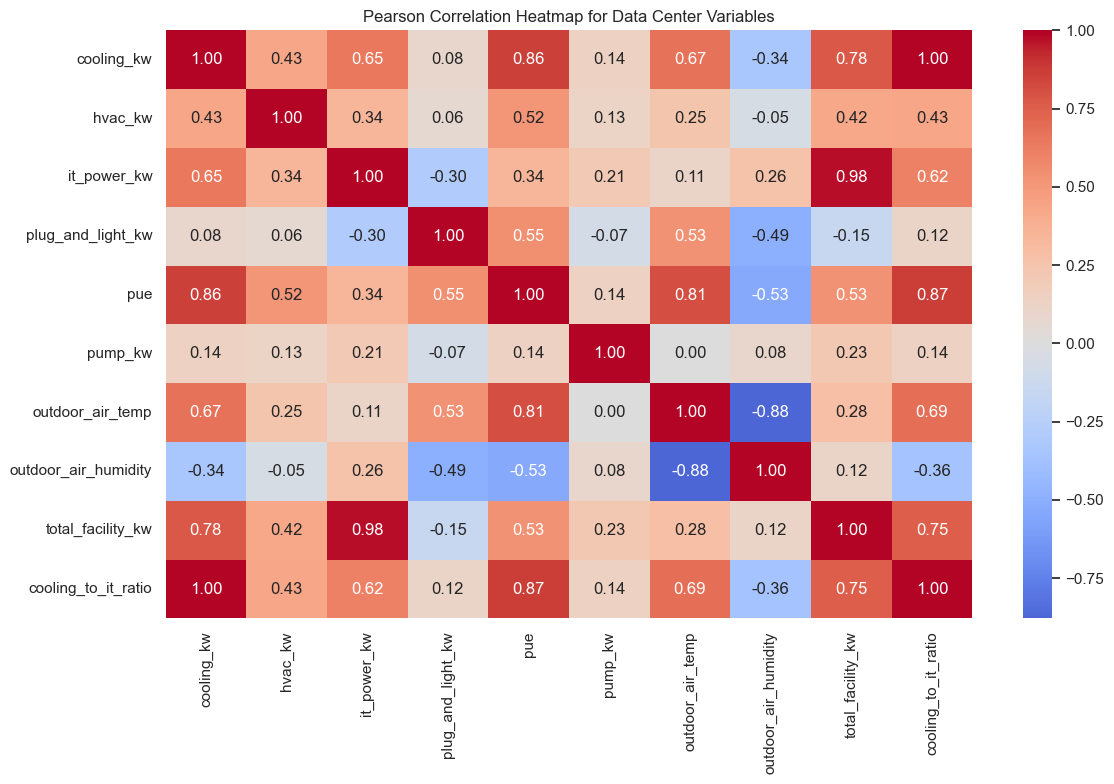

In [28]:
# Pearson correlation heatmap

plt.figure(figsize=(12, 8))
sns.heatmap(
    pearson_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Pearson Correlation Heatmap for Data Center Variables")
plt.tight_layout()
plt.show()

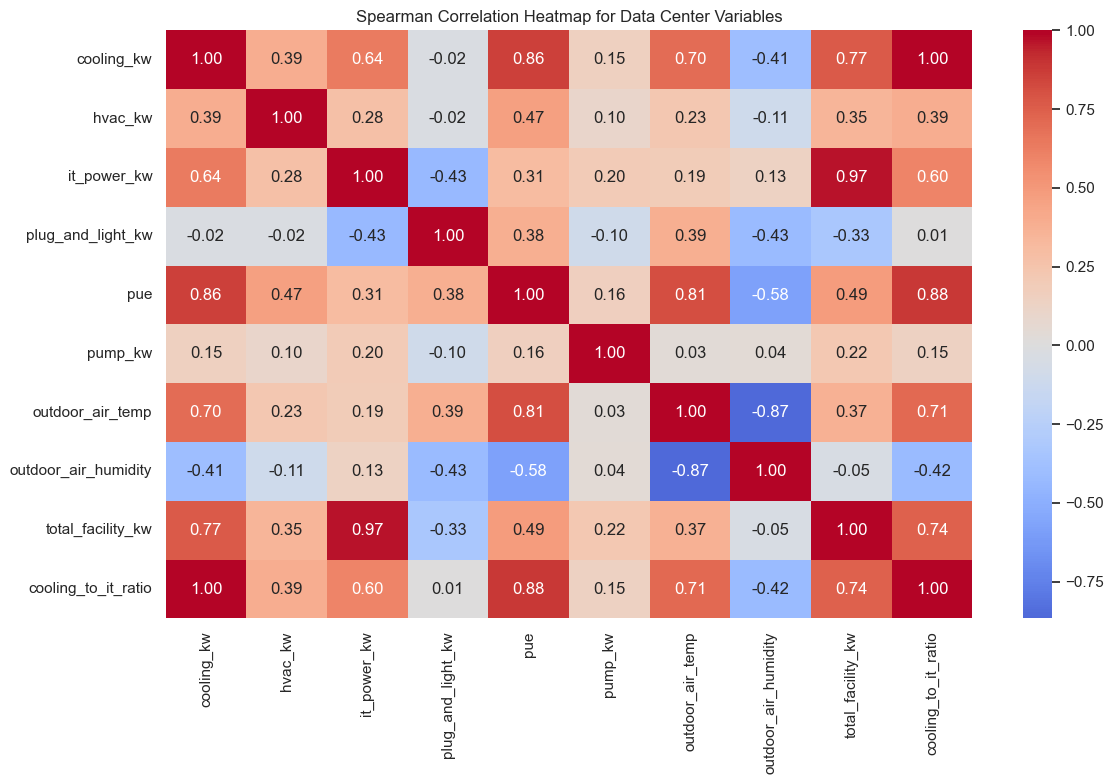

In [29]:
# Spearman correlation heatmap

plt.figure(figsize=(12, 8))
sns.heatmap(
    spearman_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Heatmap for Data Center Variables")
plt.tight_layout()
plt.show()

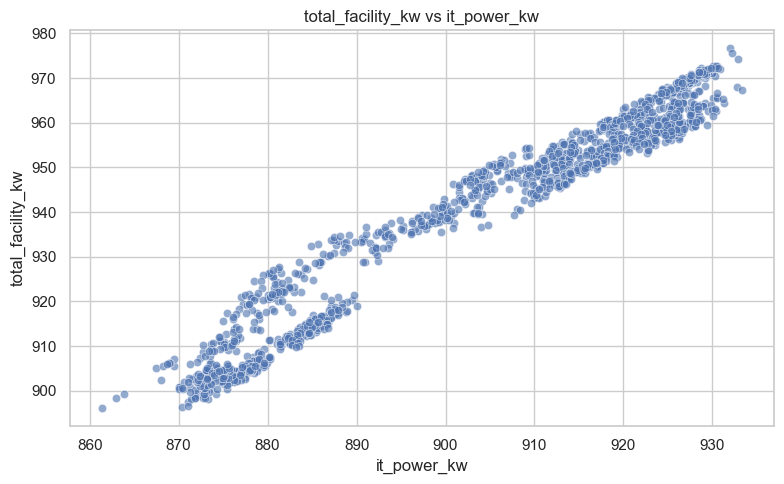

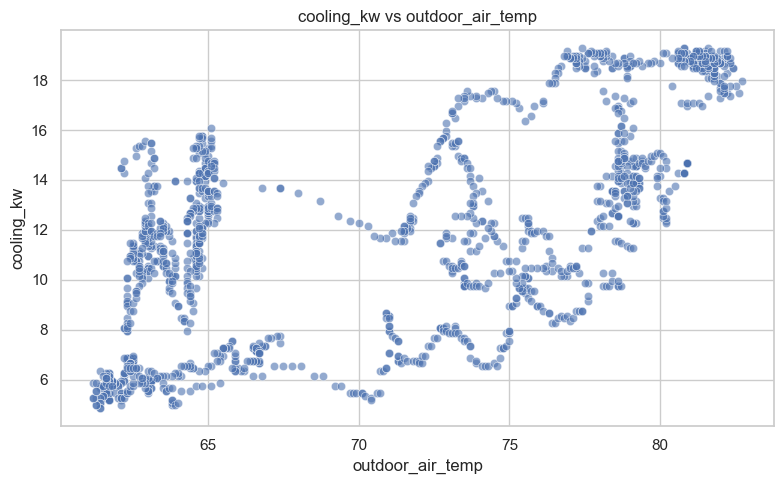

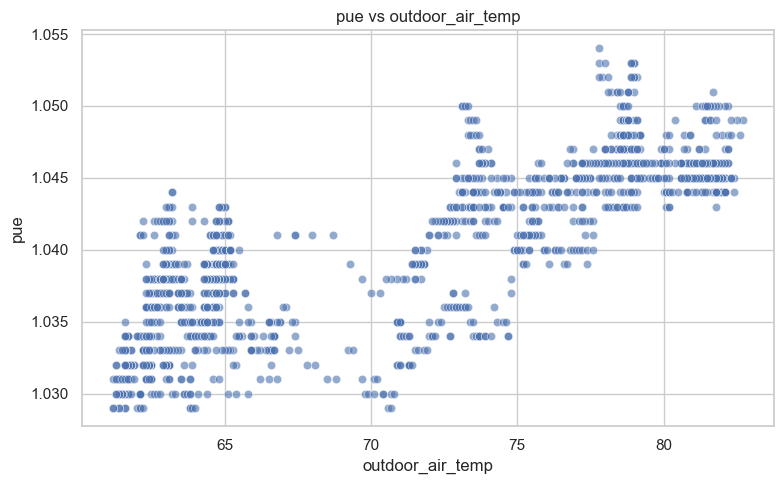

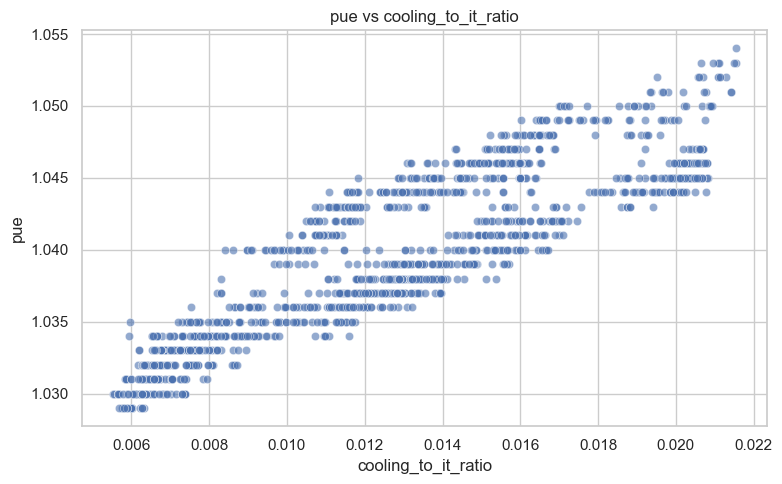

In [30]:
# Scatter plots for key engineering relationships

key_relationships = [
    ("it_power_kw", "total_facility_kw"),
    ("outdoor_air_temp", "cooling_kw"),
    ("outdoor_air_temp", "pue"),
    ("cooling_to_it_ratio", "pue")
]

for x_column, y_column in key_relationships:
    if x_column in eda_df.columns and y_column in eda_df.columns:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(
            data=eda_df,
            x=x_column,
            y=y_column,
            alpha=0.6
        )
        plt.title(f"{y_column} vs {x_column}")
        plt.xlabel(x_column)
        plt.ylabel(y_column)
        plt.tight_layout()
        plt.show()

### Correlation Analysis Interpretation

The correlation analysis compares linear and rank-based relationships between data center variables. Strong relationships between IT power, cooling power, total facility power, and PUE may indicate how computing load and cooling demand affect facility efficiency.

Relationships involving outdoor air temperature may indicate the influence of external weather conditions on cooling behavior. However, correlation should not be interpreted as causation.

## 10. Data Visualization

This section uses visual analysis to understand distributions, relationships, and categorical patterns. Each plot includes a title and axis labels.

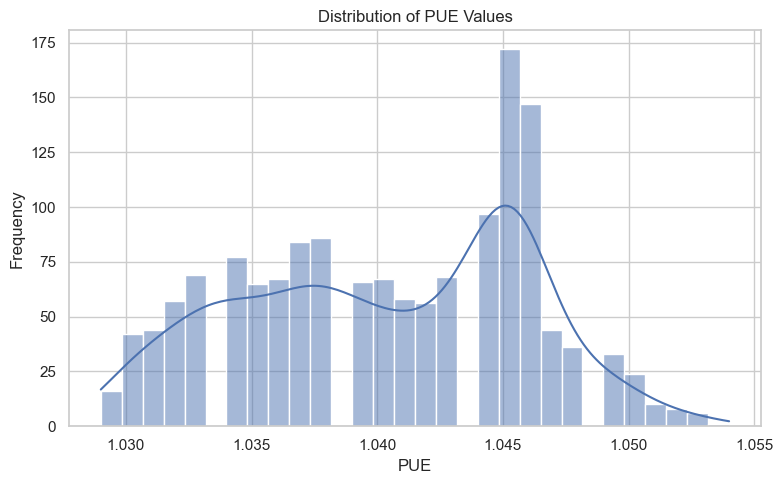

In [31]:
# Histogram

plt.figure(figsize=(8, 5))
sns.histplot(data=eda_df, x="pue", bins=30, kde=True)

plt.title("Distribution of PUE Values")
plt.xlabel("PUE")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

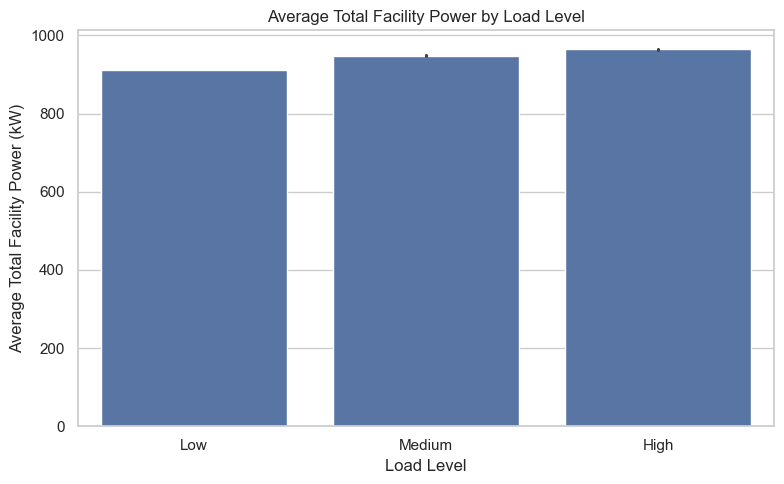

In [32]:
# Bar chart

plt.figure(figsize=(8, 5))
sns.barplot(
    data=eda_df,
    x="load_level",
    y="total_facility_kw",
    estimator="mean"
)

plt.title("Average Total Facility Power by Load Level")
plt.xlabel("Load Level")
plt.ylabel("Average Total Facility Power (kW)")
plt.tight_layout()
plt.show()

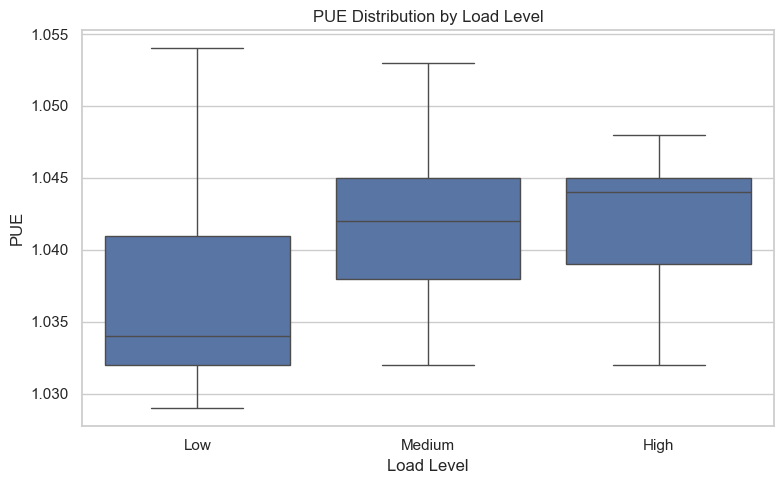

In [33]:
# Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=eda_df,
    x="load_level",
    y="pue"
)

plt.title("PUE Distribution by Load Level")
plt.xlabel("Load Level")
plt.ylabel("PUE")
plt.tight_layout()
plt.show()

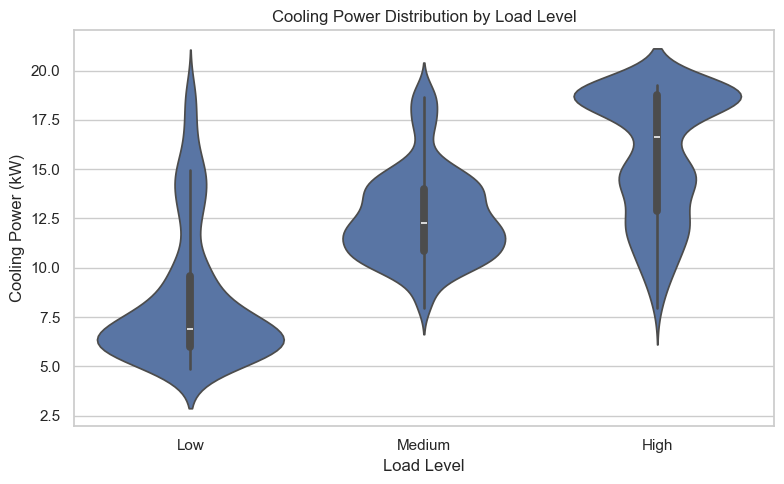

In [34]:
# Violin plot

plt.figure(figsize=(8, 5))
sns.violinplot(
    data=eda_df,
    x="load_level",
    y="cooling_kw"
)

plt.title("Cooling Power Distribution by Load Level")
plt.xlabel("Load Level")
plt.ylabel("Cooling Power (kW)")
plt.tight_layout()
plt.show()

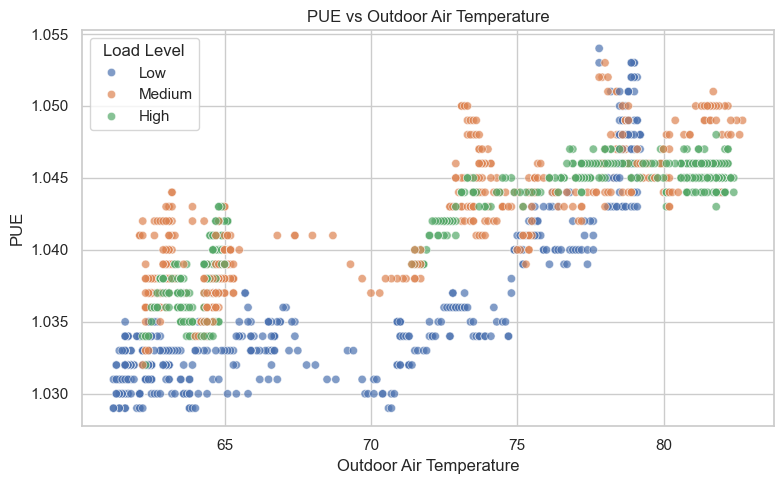

In [35]:
# Scatterplot

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=eda_df,
    x="outdoor_air_temp",
    y="pue",
    hue="load_level",
    alpha=0.7
)

plt.title("PUE vs Outdoor Air Temperature")
plt.xlabel("Outdoor Air Temperature")
plt.ylabel("PUE")
plt.legend(title="Load Level")
plt.tight_layout()
plt.show()

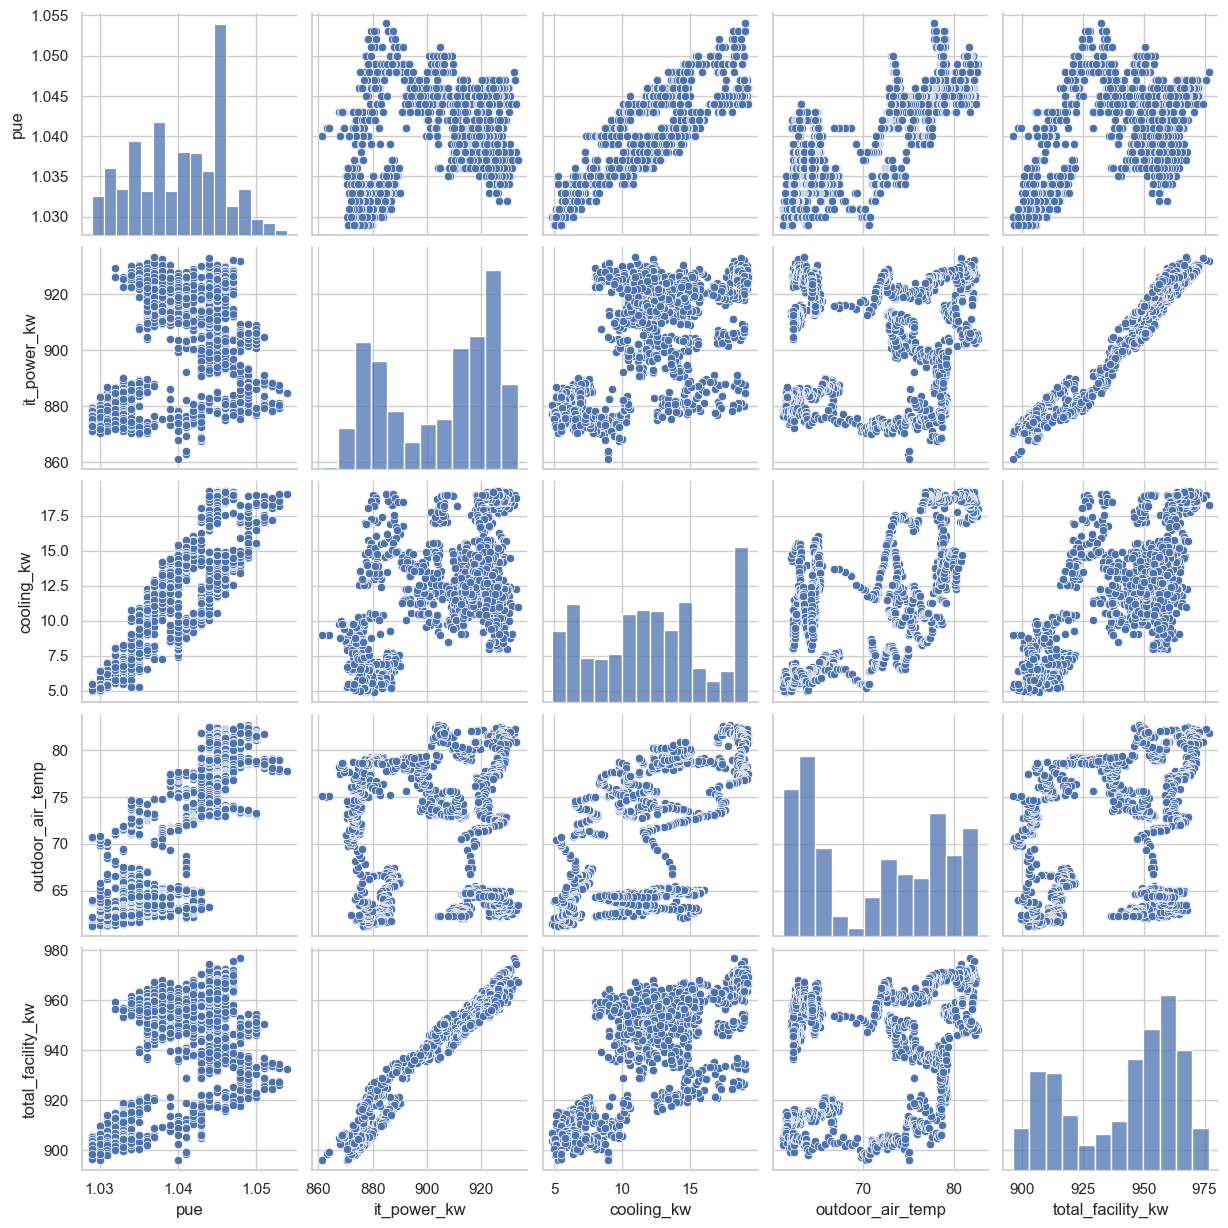

In [36]:
# Pairplot

pairplot_columns = [
    "pue",
    "it_power_kw",
    "cooling_kw",
    "outdoor_air_temp",
    "total_facility_kw"
]

sns.pairplot(
    eda_df[pairplot_columns].dropna(),
    diag_kind="hist"
)

plt.show()

In [ ]:
# PUE category distribution as a bar chart

pue_counts = eda_df["pue_category"].value_counts()

plt.figure(figsize=(7, 4))
pue_counts.plot(kind="bar")
plt.title("PUE Category Distribution")
plt.xlabel("PUE Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

pue_counts


### Visualization Interpretation

The plots provide a visual view of the distribution and relationships in the working dataset. The histogram shows the distribution of PUE values, while the bar chart, boxplot, and violin plot compare power and efficiency behavior across load levels.

The scatterplot and pairplot help examine relationships between environmental conditions, IT power, cooling power, facility power, and PUE. These visualizations support the correlation analysis and help identify potential patterns or unusual behavior.

## 11. Time-Based Index Analysis

This section analyzes the timestamp column as a time-based index. Since the dataset represents operational time-series measurements from a data center, the time index is important for ordering, uniqueness, and short-term behavior.

In [38]:
# Time-based index analysis

time_index_df = eda_df.copy()
time_index_df = time_index_df.sort_values("ts").set_index("ts")

index_analysis_summary = pd.DataFrame({
    "Question": [
        "Is the index time-based?",
        "Is the index unique?",
        "Is the index sorted?",
        "Start time",
        "End time",
        "Number of rows"
    ],
    "Answer": [
        isinstance(time_index_df.index, pd.DatetimeIndex),
        time_index_df.index.is_unique,
        time_index_df.index.is_monotonic_increasing,
        time_index_df.index.min(),
        time_index_df.index.max(),
        len(time_index_df)
    ]
})

index_analysis_summary

,Question,Answer
0,Is the index time-based?,True
1,Is the index unique?,True
2,Is the index sorted?,True
3,Start time,2016-07-28 08:45:24+00:00
4,End time,2016-07-29 09:44:21+00:00
5,Number of rows,1500


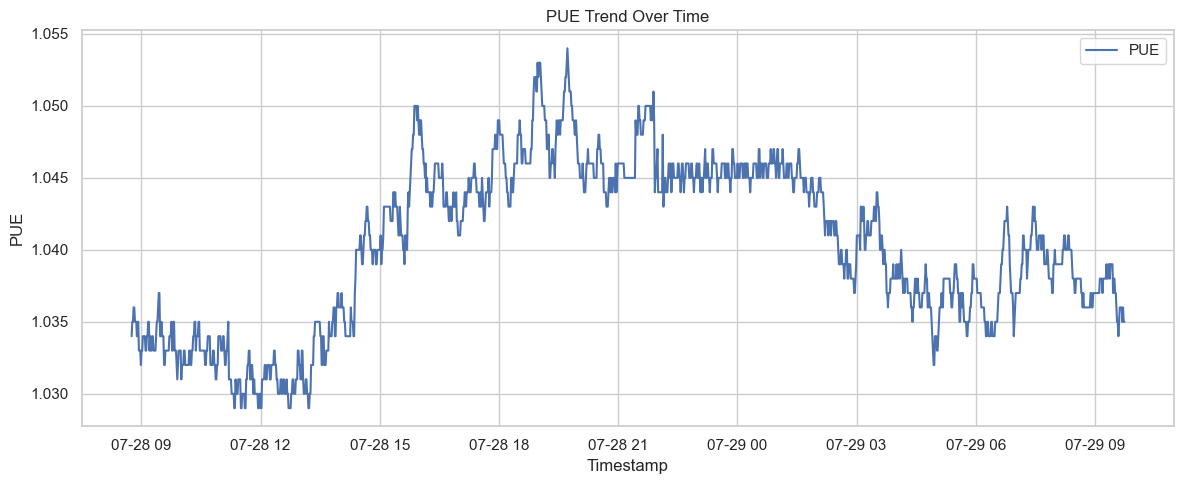

In [39]:
# PUE trend over time

plt.figure(figsize=(12, 5))

plt.plot(time_index_df.index, time_index_df["pue"], label="PUE")

plt.title("PUE Trend Over Time")
plt.xlabel("Timestamp")
plt.ylabel("PUE")
plt.legend()
plt.tight_layout()
plt.show()

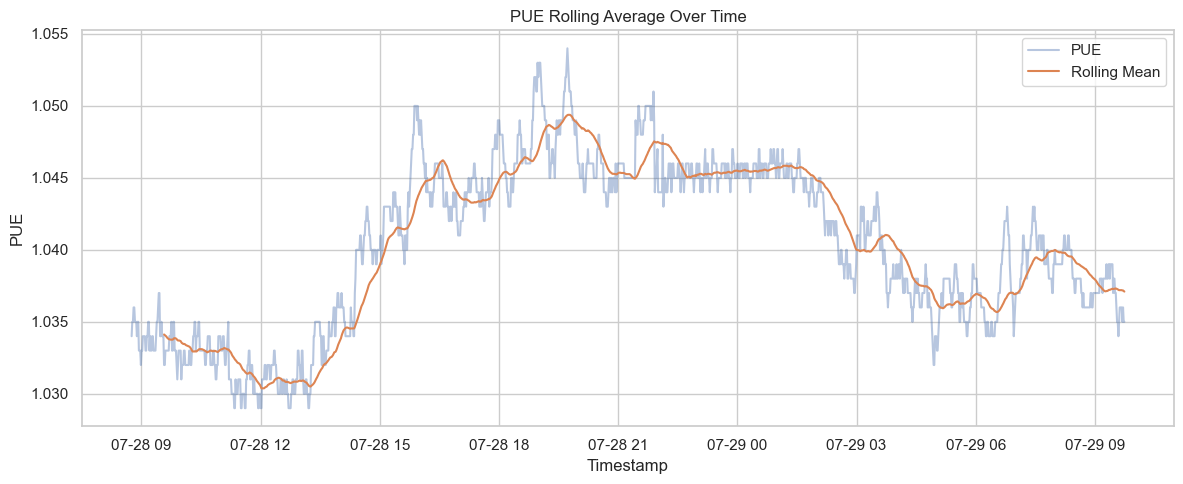

In [40]:
# Rolling average for PUE

time_index_df["pue_rolling_mean"] = time_index_df["pue"].rolling(window=50).mean()

plt.figure(figsize=(12, 5))

plt.plot(time_index_df.index, time_index_df["pue"], alpha=0.4, label="PUE")
plt.plot(time_index_df.index, time_index_df["pue_rolling_mean"], label="Rolling Mean")

plt.title("PUE Rolling Average Over Time")
plt.xlabel("Timestamp")
plt.ylabel("PUE")
plt.legend()
plt.tight_layout()
plt.show()

### Index Analysis Interpretation

The timestamp column is suitable for time-based analysis because it was converted into a datetime format and sorted chronologically.

The selected working dataset covers a short chronological time window. This is useful for short-term operational analysis, but it limits the ability to generalize conclusions to full weeks, seasons, or annual behavior.

The rolling average helps smooth short-term fluctuations and makes it easier to observe the general efficiency trend.

## 12. Data Story and Main Insights

This exploratory data analysis examined energy and weather measurements from a data center environment. The analysis focused on data quality, univariate distributions, outliers, correlations, visual patterns, and time-based behavior.

### Main Insight 1: IT load is strongly related to total facility power

The correlation analysis shows that `it_power_kw` is strongly related to `total_facility_kw`. This suggests that IT load is a major contributor to total facility power consumption in the selected working dataset.

### Main Insight 2: Cooling behavior is strongly related to PUE

The analysis shows a strong relationship between `cooling_kw` and `pue`. This is reasonable from an engineering perspective because cooling overhead affects data center energy efficiency.

### Main Insight 3: Outdoor temperature is related to efficiency behavior

The analysis shows that `outdoor_air_temp` is related to PUE and cooling-related variables. This suggests that external weather conditions may influence cooling demand and data center efficiency.

## 13. Limitations and Biases

The main limitation is that the working dataset contains only the first 1,500 valid chronological rows. Although this satisfies the assignment requirement, it represents a short time window and may not capture weekly, seasonal, or long-term operational behavior.

Another limitation is that engineered features such as `total_facility_kw`, `cooling_to_it_ratio`, `load_level`, and `pue_category` are derived from existing measurements. Therefore, correlations involving these engineered features should be interpreted carefully because they are not fully independent from their source variables.

Missing values may also be structured rather than random, because sensor systems and energy meters may report data at different intervals or experience communication gaps.

## 14. Bonus: Engineering Features

Several engineering features were created to improve the analysis:

- `total_facility_kw`: estimated total facility power based on available power components.
- `cooling_to_it_ratio`: cooling power divided by IT power.
- `load_level`: quantile-based classification of low, medium, and high load.
- `pue_category`: categorical classification of PUE efficiency.
- `hour_of_day`, `day_of_week`, and `is_weekend`: time-based operational features.

These features help connect the raw sensor data to engineering interpretation and make the dataset more useful for data center energy analysis.

## 15. Conclusion

The selected data center dataset is suitable for exploratory data analysis because it includes more than 1,000 records, more than 10 columns, numeric variables, categorical variables, and a time variable.

The analysis shows that IT power, cooling power, outdoor temperature, and PUE are important variables for understanding data center energy behavior. The strongest relationships suggest that facility efficiency is closely connected to cooling demand and IT load.

The main limitation is the use of a 1,500-row working subset. This was done to keep the notebook computationally efficient, but future work should analyze a longer time period to identify weekly, seasonal, and long-term operational patterns.